In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/raw/Version_13")

postings_df = pd.read_csv(DATA_PATH / "postings.csv")
companies_df = pd.read_csv(DATA_PATH / "companies.csv")
companies_2_df = pd.read_csv(DATA_PATH / "company_industries.csv")
employee_df = pd.read_csv(DATA_PATH / "employee_counts.csv")
job_industries_df = pd.read_csv(DATA_PATH / "job_industries.csv")
industries_df = pd.read_csv(DATA_PATH / "industries.csv")
job_skills_df = pd.read_csv(DATA_PATH / "job_skills.csv")
salaries_df = pd.read_csv(DATA_PATH / "salaries.csv")
skills_df = pd.read_csv(DATA_PATH / "skills.csv")

In [2]:
print("Duplicate job_id:", postings_df["job_id"].duplicated().sum())

Duplicate job_id: 0


In [3]:
print("Duplicate company_id:", companies_df["company_id"].duplicated().sum())

Duplicate company_id: 0


In [4]:
print("Duplicate industry_id:", industries_df["industry_id"].duplicated().sum())

Duplicate industry_id: 0


In [5]:
print("Duplicate salary_id:", salaries_df["salary_id"].duplicated().sum())

Duplicate salary_id: 0


In [6]:
print("Duplicate skill_abr:", skills_df["skill_abr"].duplicated().sum())

Duplicate skill_abr: 0


In [7]:
missing_companies=(set(postings_df["company_id"].dropna()) - set(companies_df["company_id"]))

print("Missing companies references: ", len(missing_companies))

Missing companies references:  1


In [8]:
missing_jobs = (set(job_industries_df["job_id"]) - set(postings_df["job_id"]))

print("Missing job references:", len(missing_jobs))

Missing job references: 4712


In [9]:
missing_industries = (set(job_industries_df["industry_id"]) - set(industries_df["industry_id"]))

print("Missing industry references:", len(missing_industries))

Missing industry references: 0


In [10]:
print("Missing company references:", postings_df["company_id"].isna().sum())

Missing company references: 1717


In [11]:
print("Missing company_id values:", postings_df["company_id"].isna().sum())

print("Unknown company IDs:", missing_companies)

Missing company_id values: 1717
Unknown company IDs: {23729571.0}


In [12]:
jobs_per_company = (
    postings_df.groupby("company_id")["job_id"]
    .count()
)

print(jobs_per_company.describe())

count    24474.000000
mean         4.990275
std         20.495650
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       1108.000000
Name: job_id, dtype: float64


In [13]:
industries_per_job = (
    job_industries_df.groupby("job_id")
    .size()
)

print(industries_per_job.describe())

count    127125.000000
mean          1.296425
std           0.646097
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           3.000000
dtype: float64


In [14]:
skills_per_job = (
    job_skills_df.groupby("job_id")
    .size()
)

print(skills_per_job.describe())

count    126807.000000
mean          1.685774
std           0.675907
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max           3.000000
dtype: float64


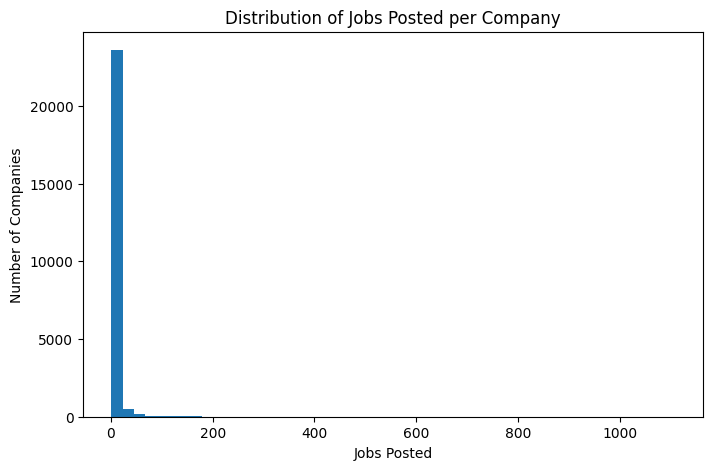

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(jobs_per_company, bins=50)
plt.title("Distribution of Jobs Posted per Company")
plt.xlabel("Jobs Posted")
plt.ylabel("Number of Companies")
plt.show()

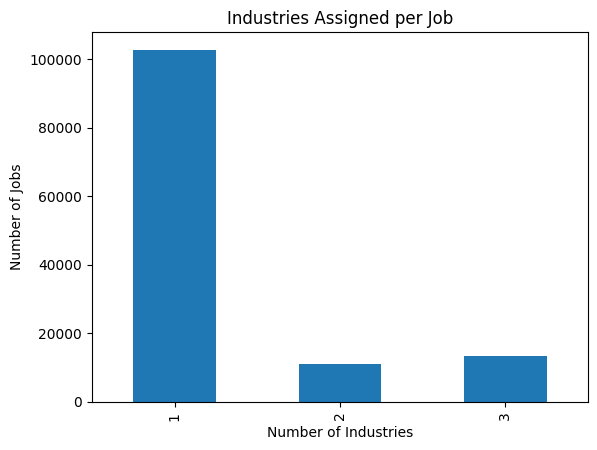

In [16]:
industries_per_job.value_counts().sort_index().plot(kind="bar")

plt.title("Industries Assigned per Job")
plt.xlabel("Number of Industries")
plt.ylabel("Number of Jobs")
plt.show()

In [17]:
postings_df["listed_time"] = pd.to_datetime(
    postings_df["listed_time"],
    unit="ms"
)

print("Earliest Date:", postings_df["listed_time"].min())
print("Latest Date:", postings_df["listed_time"].max())

Earliest Date: 2024-03-24 21:50:14
Latest Date: 2024-04-20 00:26:56


In [18]:
monthly_postings = (
    postings_df
    .groupby(postings_df["listed_time"].dt.to_period("M"))
    .size()
)

print(monthly_postings)

listed_time
2024-03         1
2024-04    123848
Freq: M, dtype: int64


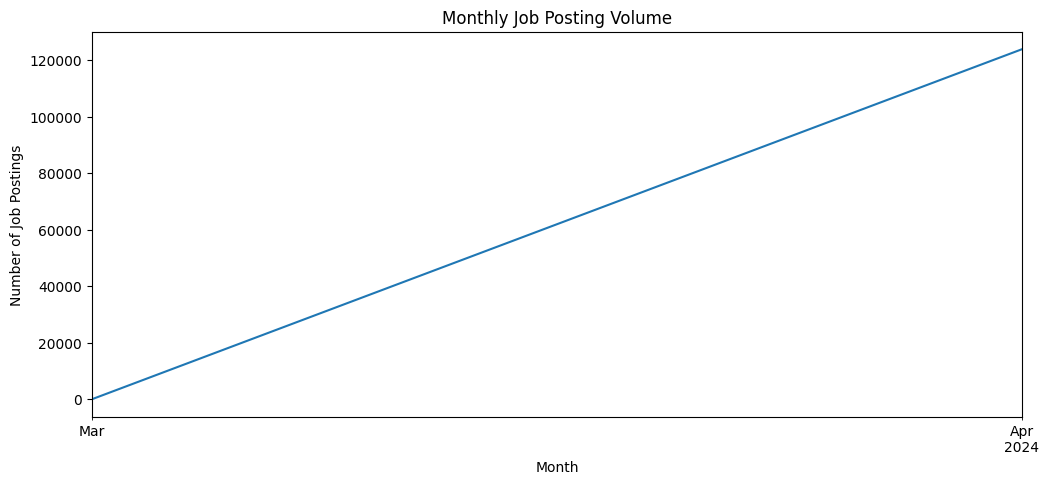

In [19]:
monthly_postings.plot(figsize=(12,5))

plt.title("Monthly Job Posting Volume")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")

plt.show()

In [20]:
time_columns = [
    "listed_time",
    "original_listed_time",
    "expiry",
    "closed_time"
]

for col in time_columns:
    print(f"\n{col}")
    print(postings_df[col].isna().sum())


listed_time
0

original_listed_time
0

expiry
0

closed_time
122776


In [21]:
postings_df["formatted_work_type"].value_counts()

formatted_work_type
Full-time     98814
Contract      12117
Part-time      9696
Temporary      1190
Internship      983
Volunteer       562
Other           487
Name: count, dtype: int64

In [22]:
postings_df["formatted_experience_level"].value_counts()

formatted_experience_level
Mid-Senior level    41489
Entry level         36708
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

In [23]:
postings_df["sponsored"].value_counts()

sponsored
0    123849
Name: count, dtype: int64

In [24]:
postings_df["remote_allowed"].value_counts()

remote_allowed
1.0    15246
Name: count, dtype: int64

In [25]:
postings_df["location"].value_counts()

location
United States                         8125
New York, NY                          2756
Chicago, IL                           1834
Houston, TX                           1762
Dallas, TX                            1383
                                      ... 
Rockport, IN                             1
Timberville, VA                          1
Koch Field, Arizona, United States       1
Oak Grove, MN                            1
Tehama, CA                               1
Name: count, Length: 8526, dtype: int64

In [26]:
time_columns = [
    "listed_time",
    "original_listed_time",
    "expiry"
]

for col in time_columns:
    temp = pd.to_datetime(postings_df[col], unit="ms")

    print(f"\n{col}")
    print("Earliest :", temp.min())
    print("Latest   :", temp.max())


listed_time
Earliest : 2024-03-24 21:50:14
Latest   : 2024-04-20 00:26:56

original_listed_time
Earliest : 2023-12-05 21:08:53
Latest   : 2024-04-20 00:26:43

expiry
Earliest : 2024-04-12 06:30:48
Latest   : 2024-10-17 00:26:36


In [27]:
postings_df["original_listed_time"] = pd.to_datetime(
    postings_df["original_listed_time"],
    unit="ms"
)

daily_postings = (
    postings_df
    .groupby(postings_df["original_listed_time"].dt.date)
    .size()
)

print(daily_postings.head())
print(daily_postings.tail())

original_listed_time
2023-12-05    1
2023-12-08    1
2023-12-21    1
2024-01-05    2
2024-01-08    1
dtype: int64
original_listed_time
2024-04-16     4328
2024-04-17    11447
2024-04-18    33603
2024-04-19    27550
2024-04-20      150
dtype: int64


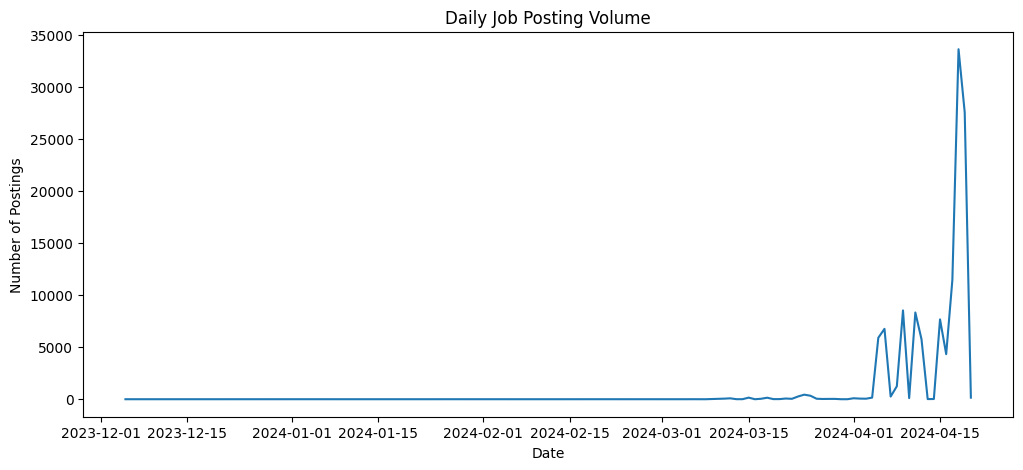

In [28]:
import matplotlib.pyplot as plt

daily_postings.plot(figsize=(12,5))

plt.title("Daily Job Posting Volume")
plt.xlabel("Date")
plt.ylabel("Number of Postings")

plt.show()